# ```MLflow``` Basics #

### Documentation ###
- ```MLflow``` Documentation - [Link](https://mlflow.org/docs/latest/getting-started/intro-quickstart/);
- ```MLflow``` Concepts - [Link](https://mlflow.org/docs/2.3.0/concepts.html);
- ```MLflow``` Tutorials (Notebooks) - [Link](https://mlflow.org/docs/latest/getting-started/logging-first-model);
- Youtube ```TeoMeWhy``` Playlist - [Link](https://www.youtube.com/watch?v=W8bxk42C9UE&list=PLvlkVRRKOYFQeQEA5Lc0US9i-EK8eGgrs);
- Git ```TeoMeWhy``` Repo - [Link](https://github.com/TeoMeWhy/curso-mflow/tree/main);

### Importing Dependencies ###

In [2]:
from IPython.display import Image 



---

### What is ```MLflow```? ###
```MLflow``` is an open-source platform, built to assist ML practitioners in handling the complexities of the MLOps process. It's a ```component``` (like a database or a data viz platform) that focuses on the full lifecycle for ML projects, ensuring that each phase is manageable, traceable, and reproducible. 

### ```Tracking``` ###
```Tracking``` component is an API/UI for logging parameters, code versions, metrics, and output files when running your ML code. ```Tracking``` is organized around the concept of ```runs```, which are executions of some piece of code. Each ```run``` records the following information:
- *Code Version*: ```git commit``` hash used for the ```run``` (from an ```MLflow``` Project);
- *Start & End Time*: ```run```'s start/ end times;
- *Source*:  file/project name to launch the ```run``` (from an ```MLflow``` Project);
- *Parameters*: ```key-value``` input parameters of choice (both must be strings);
- *Metrics*: ```key-value``` metrics, where ```value``` is numeric (each metric can be updated throughout the ```run```);
- *Artifacts*: output files in any format;

<br>**Run**<br>
A ```run``` refers to a single execution of a model training event.

**Experiments**<br>
```Experiments``` are essentially named groups of ```runs``` (entities under which related ```runs``` reside; for example: runs with different parameters, different data, etc). 

**Recording Runs**<br>
```Runs``` can be recorded to local files (via a SQLAlchemy-compatible DB) or remotely to a tracking server. By default, the Python API logs runs locally to files in an ```mlruns``` directory wherever the code is ran.

For storing ```runs``` and ```artifacts```, ```MLflow``` uses 2 components for storage: ```backend store``` and ```artifact store```. While the first persists ```entities``` (runs, parameters, metrics, tags, notes, metadata, etc), the later persists ```artifacts``` (files, models, images, in-memory objects, or model summary, etc). The client can interface with a variety of backend/artifact storage configurations.

### ```Projects``` ###
An ```MLflow Project``` is a format for packaging code in a reusable and reproducible way (a convention for organizing and describing code to let others run it). Each ```project``` is simply a directory of files (or git repo) containing code. We can describe a ```project``` in more detail by adding a ```MLproject file``` (YAML text file). Each ```project``` can specify several properties:
- *Name*: name for the project;
- *Entry Points*: commands that can be run within the ```project``` and information about parameters;
- *Environment*: software environment that should be used to execute project ```entry points``` (including all library dependencies);

By default, any git repository or local directory can be treated as an ```MLflow project``` and any bash or Python script contained in the directory as a project ```entry point```. 

**Running Projects**<br>
```MLflow``` provides 2 ways to run ```projects```: the ```mlflow run``` CLI or ```mlflow.projects.run()``` Python API. Both take the following parameters:
- *Project URI*: directory on local file system or git repo, specified in URI form (```https://<repo>``` or ```user@host:path```). To run against a file located in a subdirectory of the project, add a ```#``` to the end of the URI argument, followed by the relative path from the project's root to the desired subdirectory;
- *Project Version*: the commit hash or branch name (for git-based projects);
- *Entry Point*: name of the ```entry point``` (defaults to ```main```). We can use any ```entry point``` named in the ```MLproject file```, given as a path from the project root;
- *Parameters*: ```key-value``` parameters;
- *Deployment Mode*: CLI/API let us launch projects remotely (in a ```Databricks``` environment);
- *Environment*: ```MLflow Projects``` are run in the environment specified by the project directory (or ```MLproject file```). We can ignore a project’s specified environment and run it in the current system environment with ```--env-manager=local``` flag (this can lead to unexpected results if dependency mismatch);

### ```Models``` ###
Each ```MLflow Model``` is a directory containing arbitrary files, together with an ```MLmodel``` file in the root that define the ```flavor``` that the model can be viewed in. ```Models``` are essentially named groups of ```experiments``` (above).

**Flavors**<br>
```Flavors``` are the key concept that makes ```MLflow Models``` powerful: they are a *convention that deployment tools can use to understand the model* (not needing integrations for deployment). For example, ```mlflow.sklearn``` allows loading models as a ```scikit-learn``` Pipeline object which is aware of ```scikit-learn```.

Apart from a ```flavors``` field listing the model's flavors, the ```MLmodel YAML``` can contain the following fields:
- *time_created*: date/time when the model was created (in UTC ISO 8601);
- *run_id*: ID of run that created the model (if model was saved using ```MLflow Tracking```);
- *signature*: model signature (in JSON);
- *input_example*: reference to an artifact with input example;
- *databricks_runtime*: ```Databricks``` runtime version and type (if  model was trained in Databricks notebook/job);
- *mlflow_version*: version of ```MLflow``` used to log the model;

**Model Signature**<br>
The ```Model signature``` defines the ```schema``` of a model’s inputs/outputs. Model inputs and outputs can be either column-based (described as a sequence of named columns and types) or tensor-based (described as a sequence of named tensors and types).

To include a ```signature``` with your model, pass a ```signature``` object as an argument to the appropriate ```log_model``` call.

**Model Input Example**<br>
Similar to ```signatures```, model ```inputs``` can be column-based (```DataFrames```) or tensor-based (```numpy.ndarrays```). A model ```input example``` provides an instance of a valid model input and are stored with the model as separate ```artifacts```.

To include an ```input example``` with your model, add it to the appropriate ```log_model``` call.

**Model Evaluation**<br>
After building and training the ```Model```, we can use ```mlflow.evaluate()``` to evaluate its performance on one or more datasets, computing a variety of task-specific performance metrics (default or custom), model performance plots, and model explanations.

### ```Model Registry``` ###
The ```Model Registry``` component is a centralized model store, that provides model lineage (which ```experiment``` and ```run``` produced the model), versioning, stage transitions and annotations. Basically, from all ```experiments```, we want to register the best ```run``` and put it in production.

A few concepts describe the lifecycle of an ```Model```:
- *Model*: ```MLflow Model``` is created from an ```experiment``` or ```run``` that is logged with one of the model ```flavor```;
- *Registered Model*: a registered ```Model``` has a unique name, versions, transitional stages, lineage and other metadata;
- *Model Version*: each registered ```Model``` can have one or many versions (when a new model is added to the ```Registry```, it's added as version 1 or incremented);
- *Model Stage*: each distinct model version can be assigned one stage (such as ```Staging```, ```Production``` or ```Archived```) at any given time;
- *Annotations and Descriptions*: annotate the top-level model and each version individually using ```Markdown```, including description or any relevant information;

**Adding a Model to Model Registry**<br>
There are 3 ways to add a model to the registry:
- Via ```log_model()``` method (if registered model has a name that doesn’t exist, registers a new model and creates version 1; otherwise iterates the version);
- Via ```register_model()``` method (requires the the ```run_id``` as part of ```runs:URI``` argument);
- Via ```create_registered_model()``` to create an empty registered model with no version associated (if model name exists, throws ```MlflowException```);

**Fetching an MLflow Model from the Model Registry**<br>
After a model is registered, we can fetch a specific version and/or stage using ```load_model()```. A list of registered models can also be fetched via ``` search_model_versions()``` (filtered by ```name```).

**Transitioning Model Stage**<br>
We can move specific model versions into a desired stage, using ```transition_model_version_stage()```.

**Deleting Model**<br>
We can either delete specific versions of a model or delete all versions of a model via ```delete_model_version()```.

---

### Instalation ###
The regular version of ```MLflow``` can be installed via ```pip3 install mlflow```. If we want extra ML libraries and 3rd-party tools we can use ```pip3 install mlflow[extras]```. Finally, if we want a lightweight version we can use ```pip3 install mlflow-skinny```.

But first, from ```Terminal```, let's [create and activate the virtual environment](https://packaging.python.org/en/latest/guides/installing-using-pip-and-virtual-environments/) (```venv```):

In [ ]:
# Setting up venv in Terminal (at project directory)
python3 -m venv .mlflow_venv # Creates a '.venv' directory in project folder
source .mlflow_venv/bin/activate # Activates the venv
# Installing MLflow
pip3 install mlflow

### Start a ```Tracking``` Server ### 
We're going to start a local ```MLflow Tracking``` Server, which we'll connect to for logging our data. From ```Terminal```:

In [ ]:
# Initializing the Tracking Server
mlflow server --host 127.0.0.1 --port 8080

Once the server is online, we can access ```http://127.0.0.1:8080``` (copied from output) in the browser to gain access to the UI. To exit the server, we can run ```Ctrl + C``` in ```Terminal```.

Another important thing is that ```MLflow``` creates the ```mlruns``` folder in the directory we run the server. This folder is the default local storage location for ```entities``` and ```artifacts```.

### Creating the Model ###
In the server UI, we go into the ```Models``` tab (up top) and ```Create Model``` (with name, description and tags). At this moment, there's no real model yet, just the ```Model``` entity.

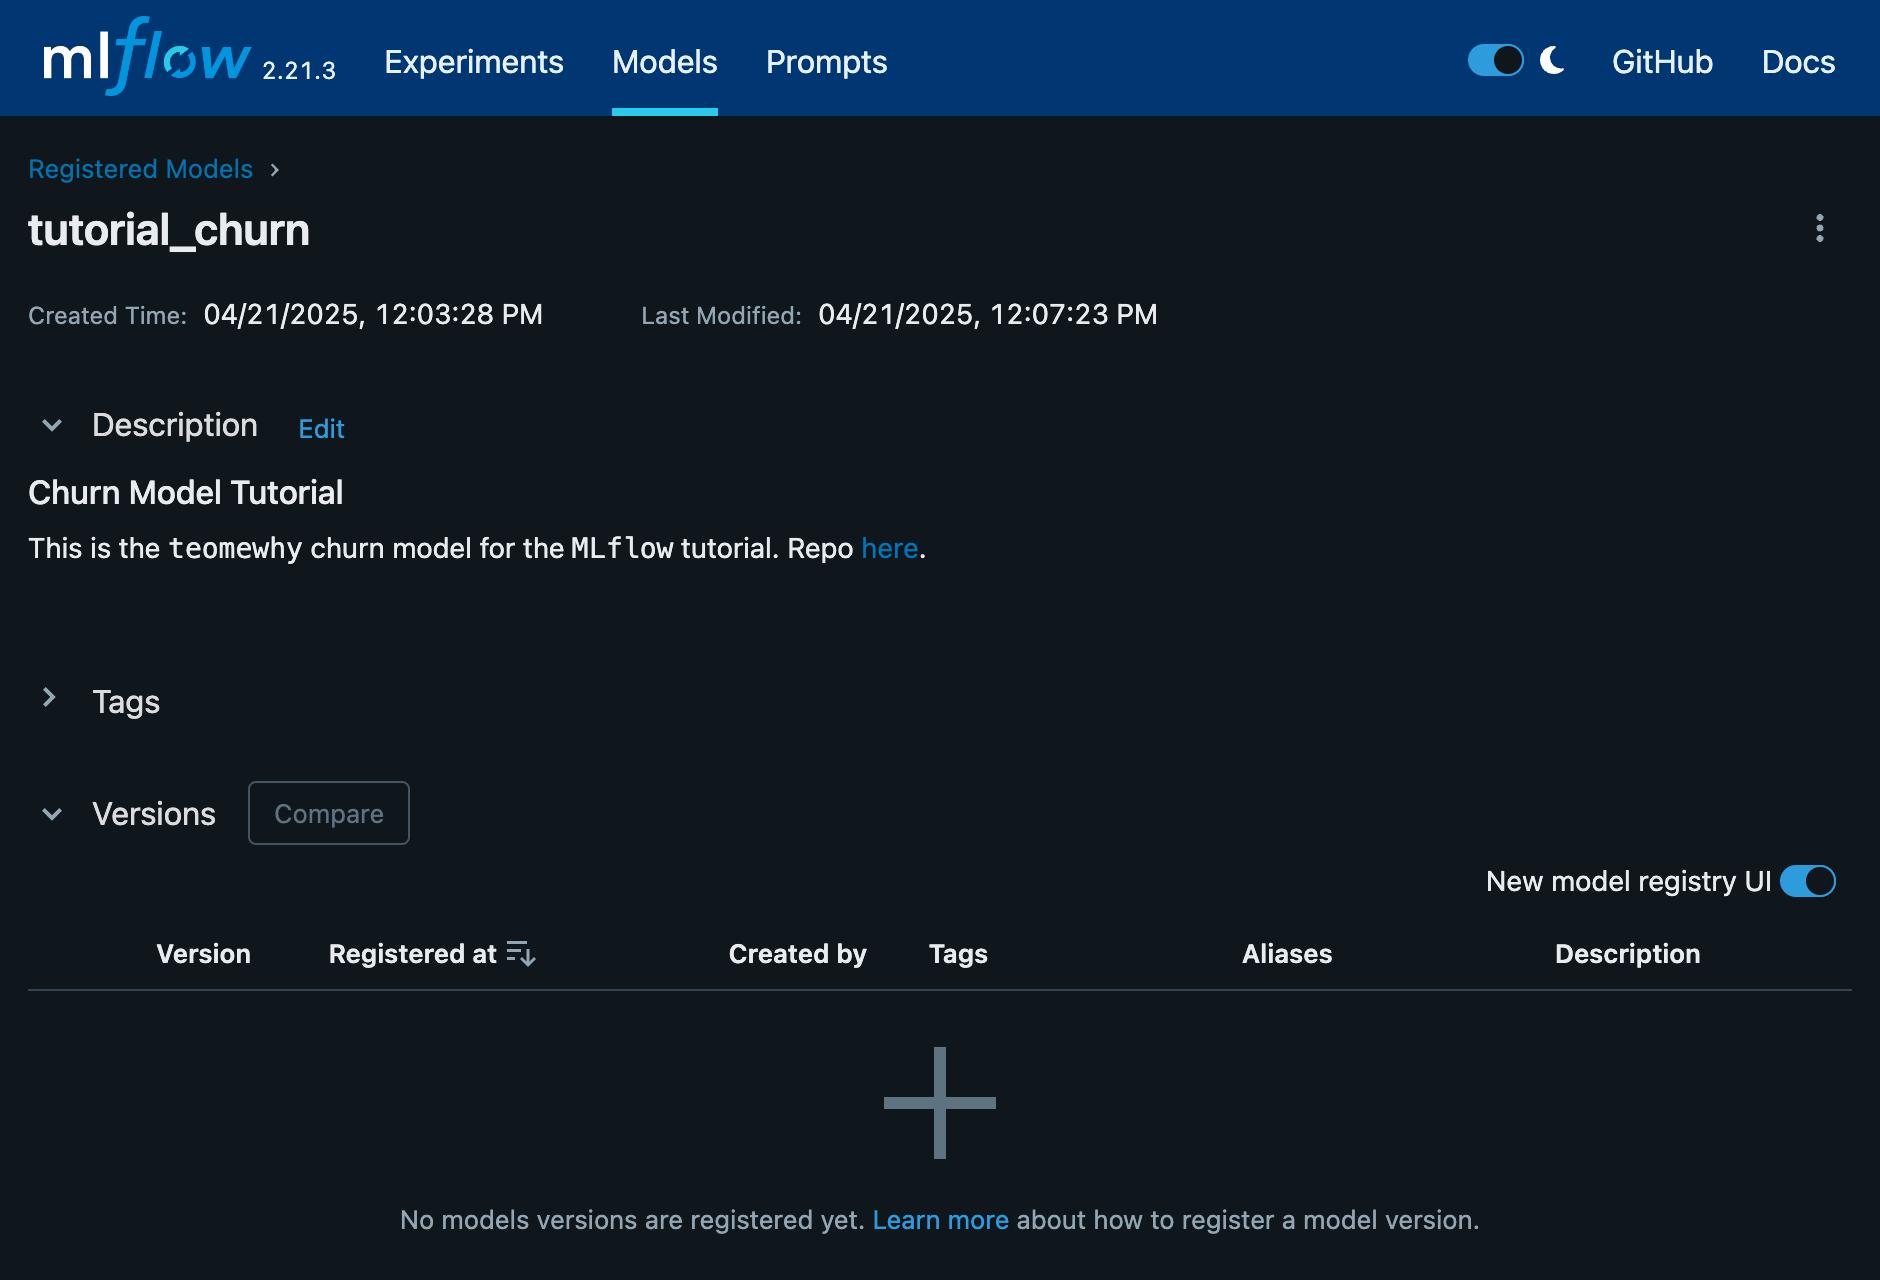

In [3]:
# Creating the 'tutorial_churn' Model entity
Image(filename= "./img/model_creation.png", width=600)

### Creating Experiments ###
In the server UI, we go into the ```Experiments``` tab (up top) and click the ```+``` button (top left) to create a ```New experiment``` (with name). Again, we're only creating the ```Experiment``` entity (without any ```runs``` yet).

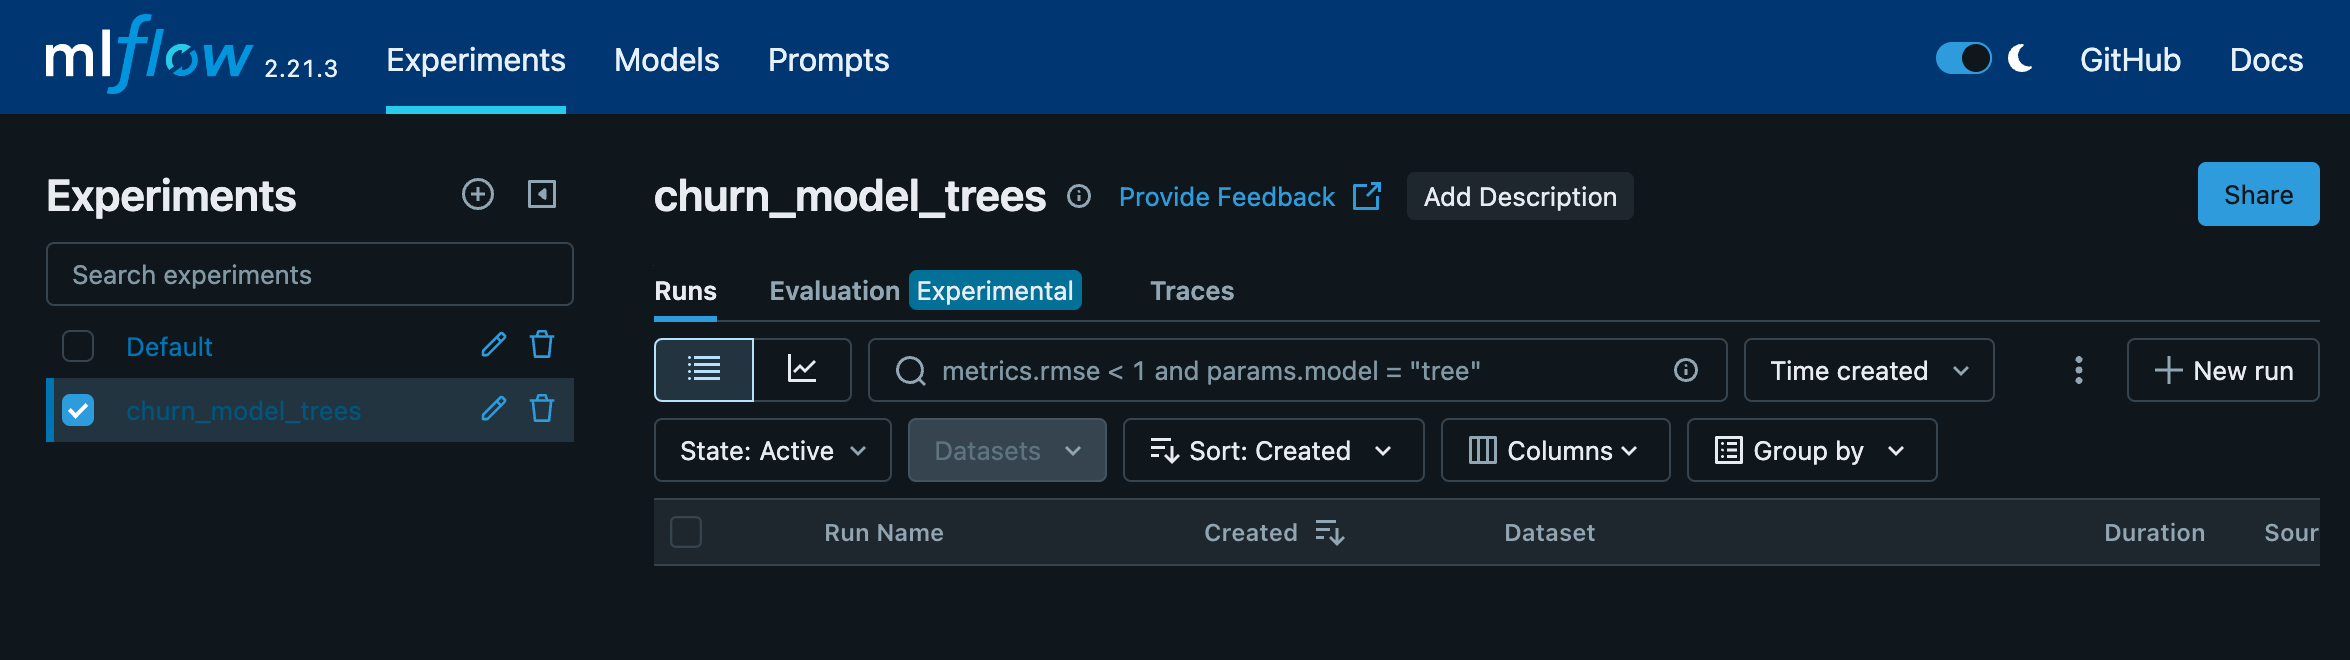

In [4]:
# Creating the 'tutorial_churn' Model entity
Image(filename= "./img/experiment_creation.png", width=800)

### Coding the Churn ML Algorithm ###
Now we leave the ```MLflow``` UI for a while and go back to ```VSCode``` to code our ML project (a churn model based on ```model_churn > data > churn_data.csv```, where ```flag_churn``` indicates wheter the customer churned or not). 

Ideally we would separate the ```MLflow venv``` and the model's ```venv```, however we'll use the same environment (to keep it simple). We create the ```train.py``` file, select our interpreter (```.mlflow_venv```, which has ```mlflow``` already installed) and proceed to code the model.

We'll use ```scikit-learn ```'s ```DecisionTree``` and ```RandomForest``` classifiers, and explore different parameters (in the ```train.py``` file). With that in mind, here are the main steps in building the model and implementing ```MLflow``` around it:

<br>**Setting the Tracking URI**<br>
We inform the server location to ```set_tracking_uri()``` (a local path file, HTTP URI or Databricks workspace).

**Setting the Experiment**<br>
Back in the server UI, we select the ```experiment```, get its ID (```i``` next to its name) and pass it as an argument to ```set_experiment()```. 

**Ready Data**<br>
We read the CSV and split it into ```train``` and ```test``` DataFrames (making sure to separate ```X``` and ```y```).

**Monitor Model**<br>
We start a new ```run```, by encapsulating the model with ```start_run()```. This sets it as the active run under which metrics and parameters will be logged. If we use a *context manager* we don't need to call ```end_run()``` to terminate the current run.

This ```with``` block starts with ```sklearn.autolog()``` to enable (or disable) autologging for ```sklearn``` (the ```flavor``` allows automatic logging of basic metrics/features). We also log custom metrics (```acc_train``` and ```acc_test```) via ```log_metrics()```.

**Run Model**<br>
Once ran, the model signals the logging and the ```run``` creation (```funny-mare-773```), providing links to both ```run``` and the ```experiment``` it belongs.

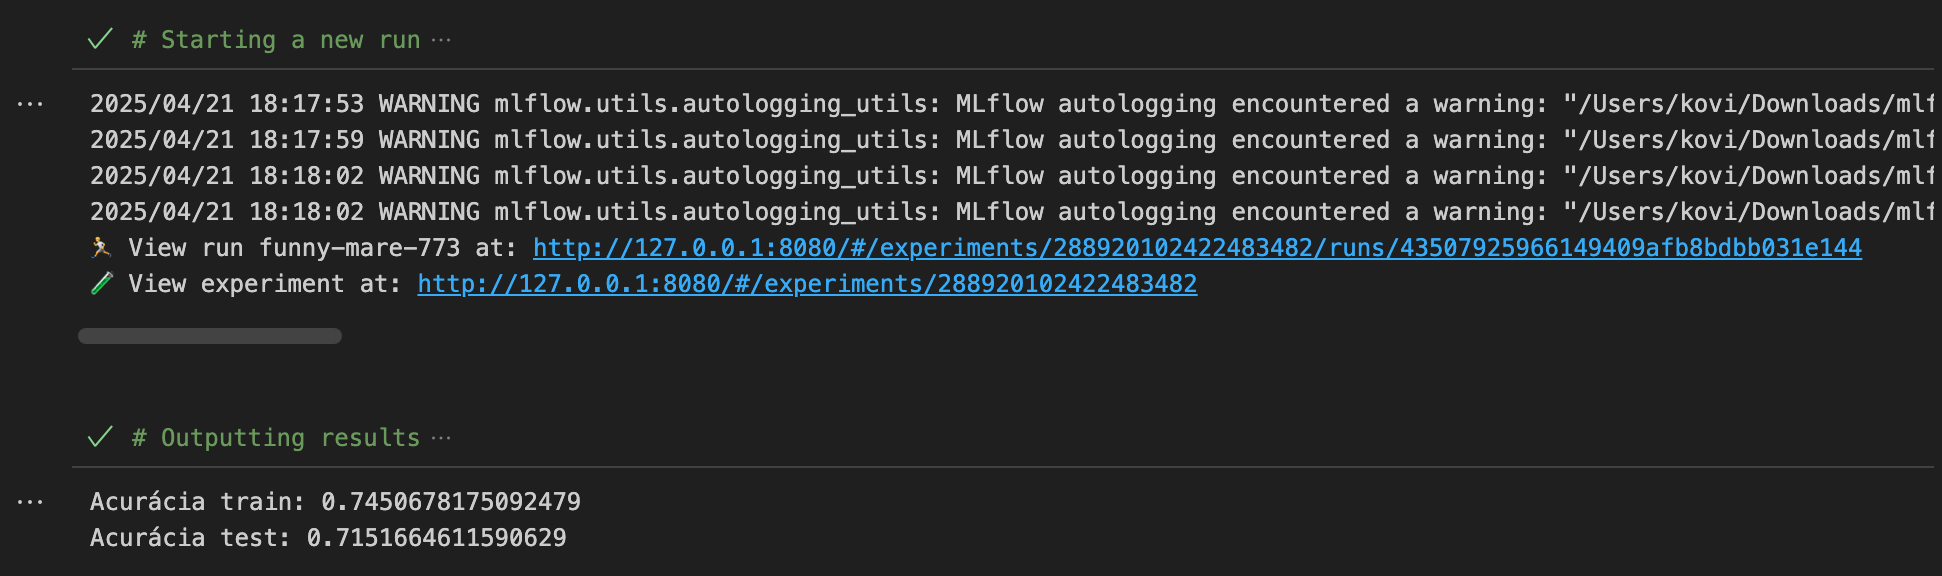

In [5]:
# Confirming the run success
Image(filename= "./img/run_1_output.png", width=800)

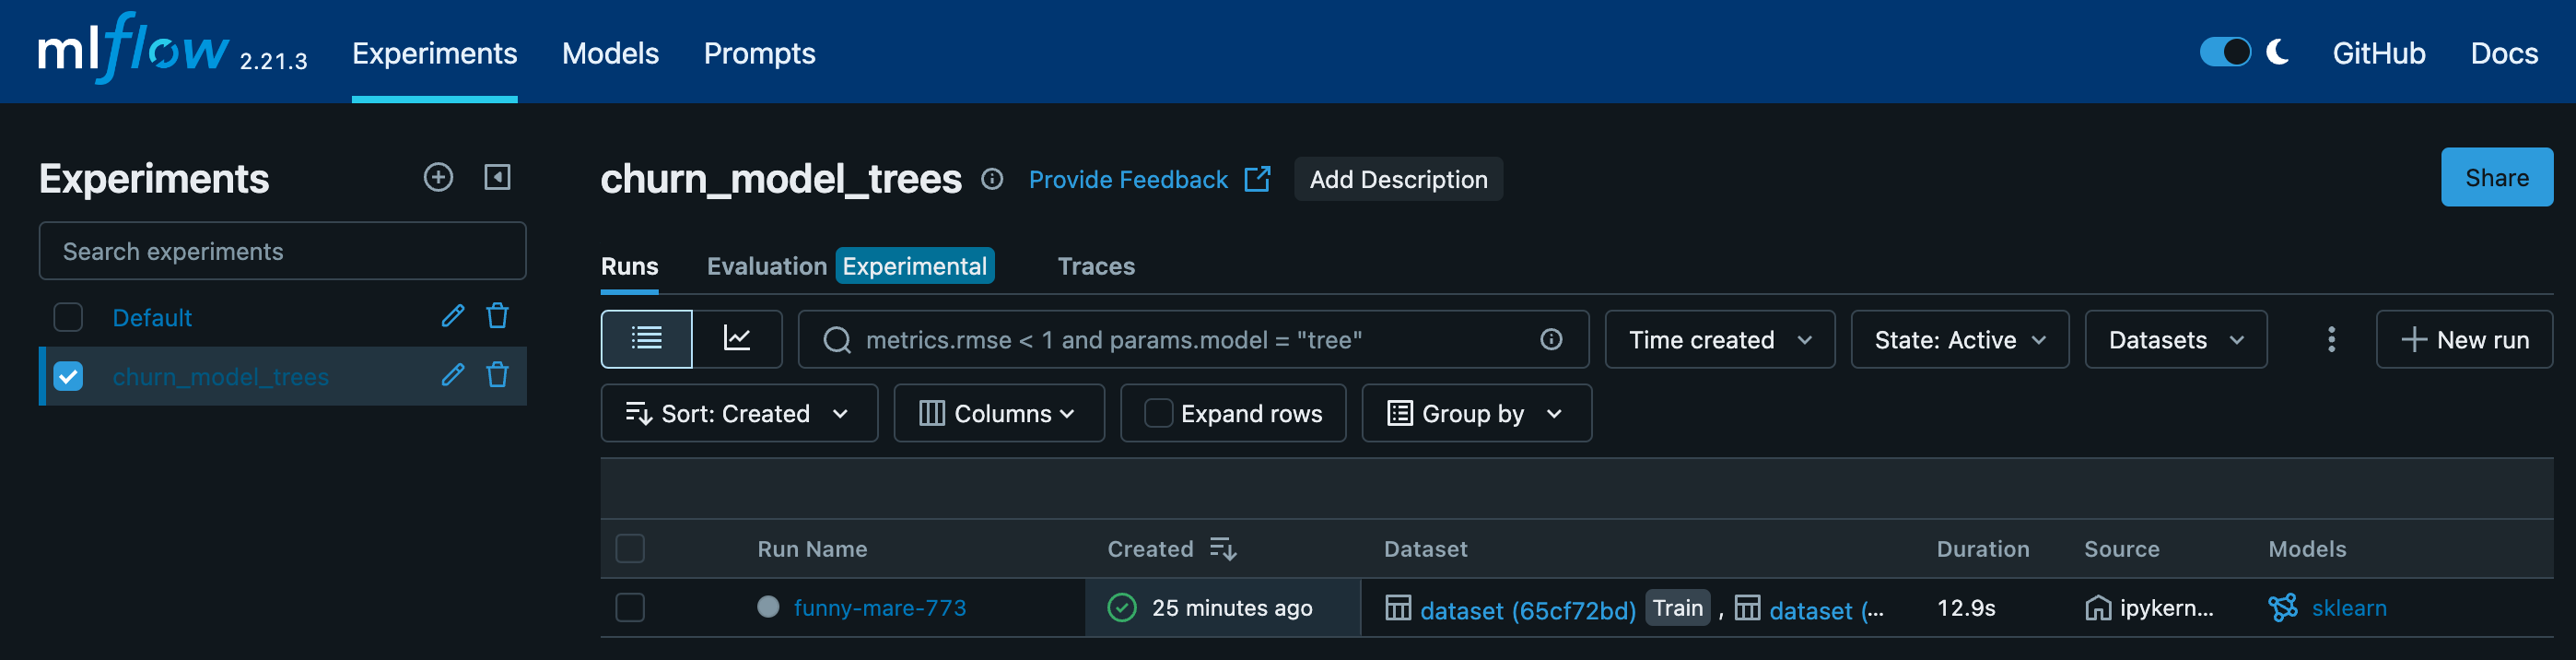

In [6]:
# Confirming the logging in the UI
Image(filename= "./img/run_1_ui.png", width=800)

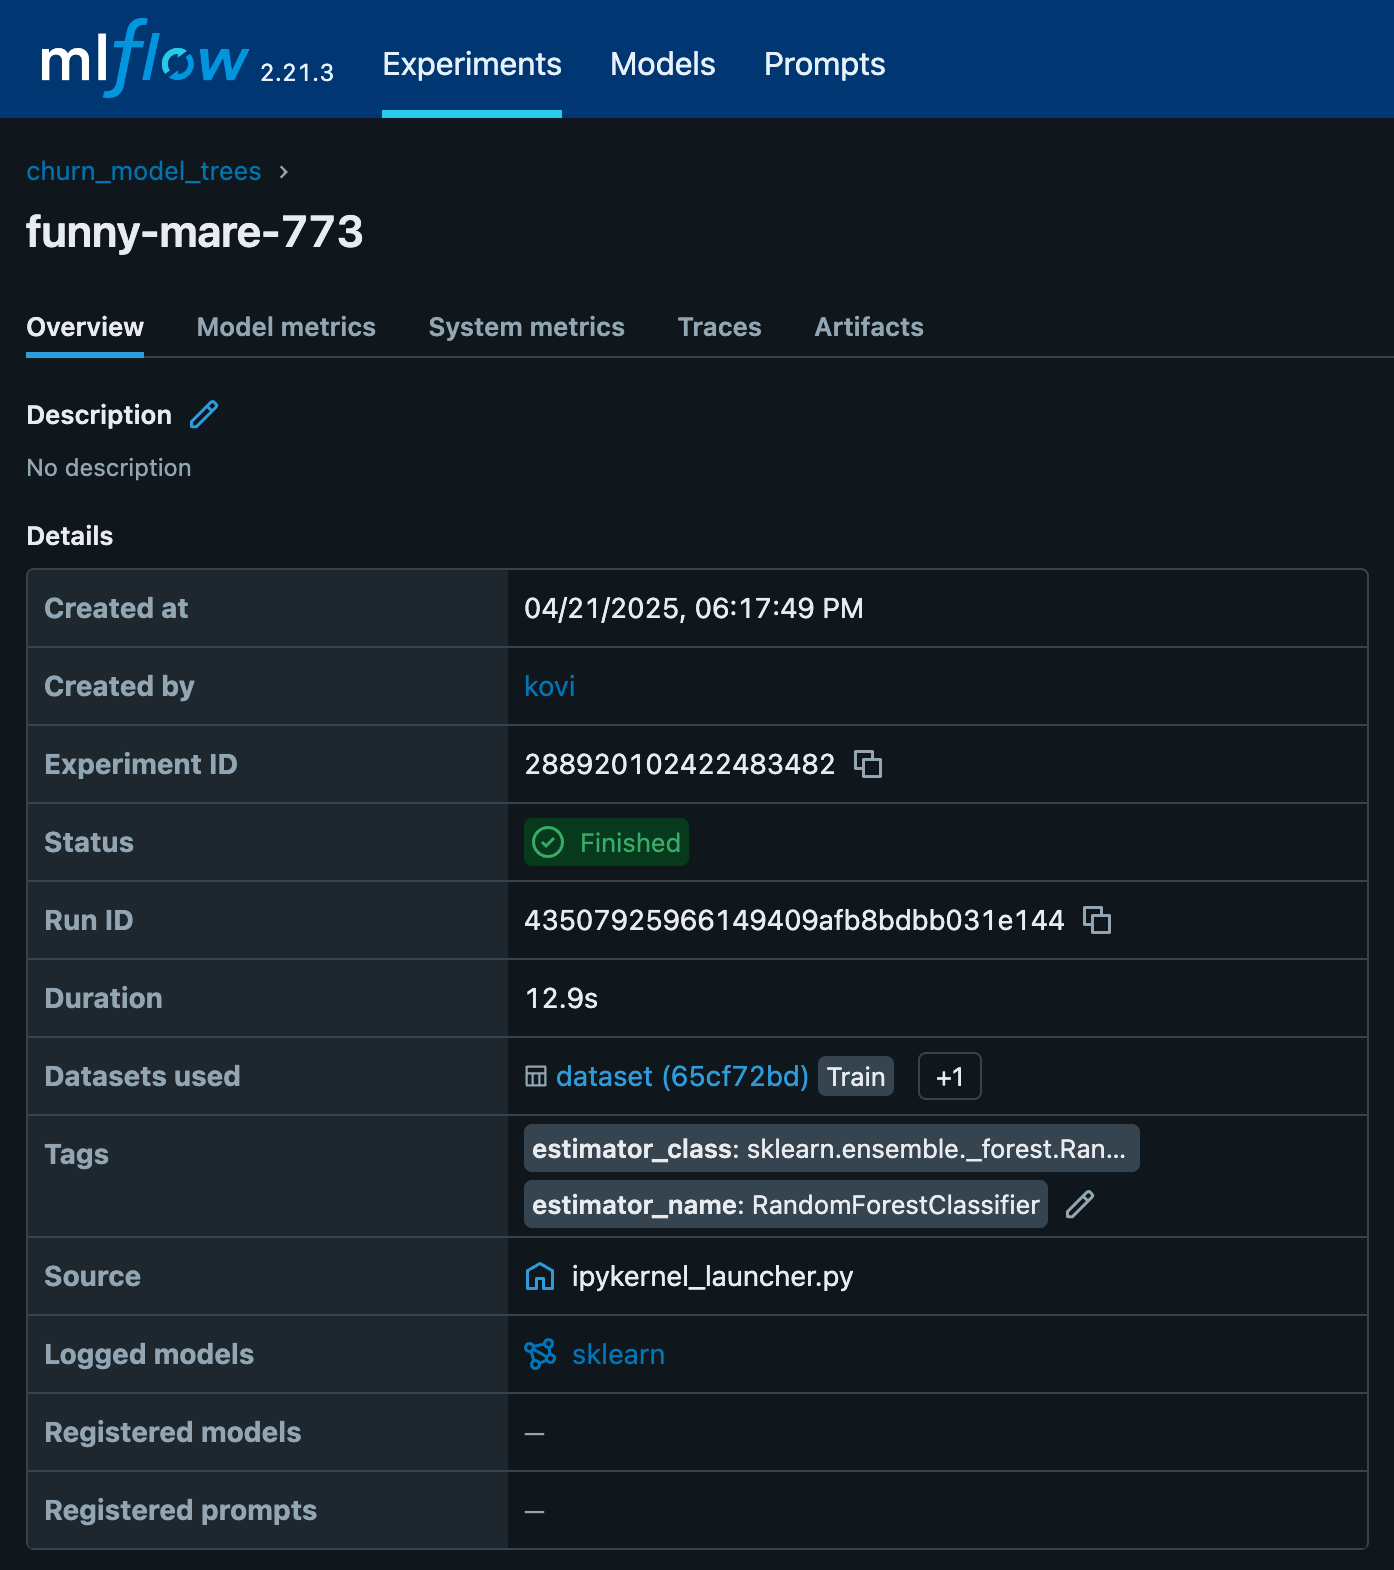

In [14]:
# Entering the run results
Image(filename= "./img/run_1_ui_details.png", width=450)

If we go into the ```Logged models``` section (in the ```run``` results), we can check all the artifacts generated with  ```autolog()```, including:
- *Binary*: ```.pkl``` file (to be used in production);
- *Requirements*: ```requirements.txt``` file (necessary libraries for the model to work; also available in ```.yaml``` format);
- *Model Signature*: with input variables ```schema```;
- *Estimator*: the model configuration used for predictions;
- *Confusion Matrix*: providing normalized results (and ```Type I```/```Type II``` errors);
- *ROC Curve*: graph that represents the performance of a binary classification model;

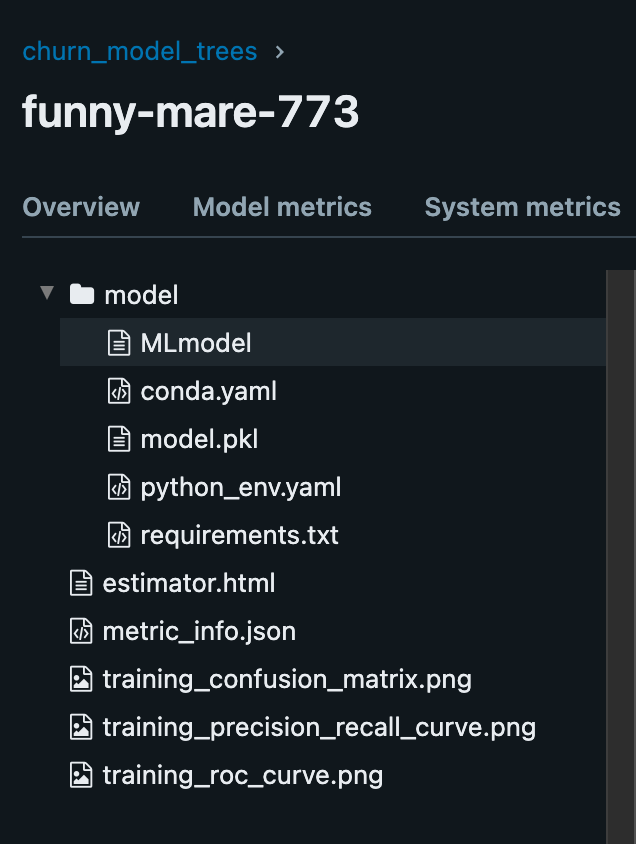

In [13]:
# Checking run's logged assets
Image(filename= "./img/run_1_assets.png", width=250)

To make sure we select the best ```run``` in the ```experiment```, we enable the custom accuracy metrics (```acc_train``` and ```acc_test```) in the ```Runs``` section. Note that we can track the ```dataset```, ```user``` and ```version``` used for the ```run```, and even model parameters (like ```min_samples_leaf``` and ```min_samples_split```).

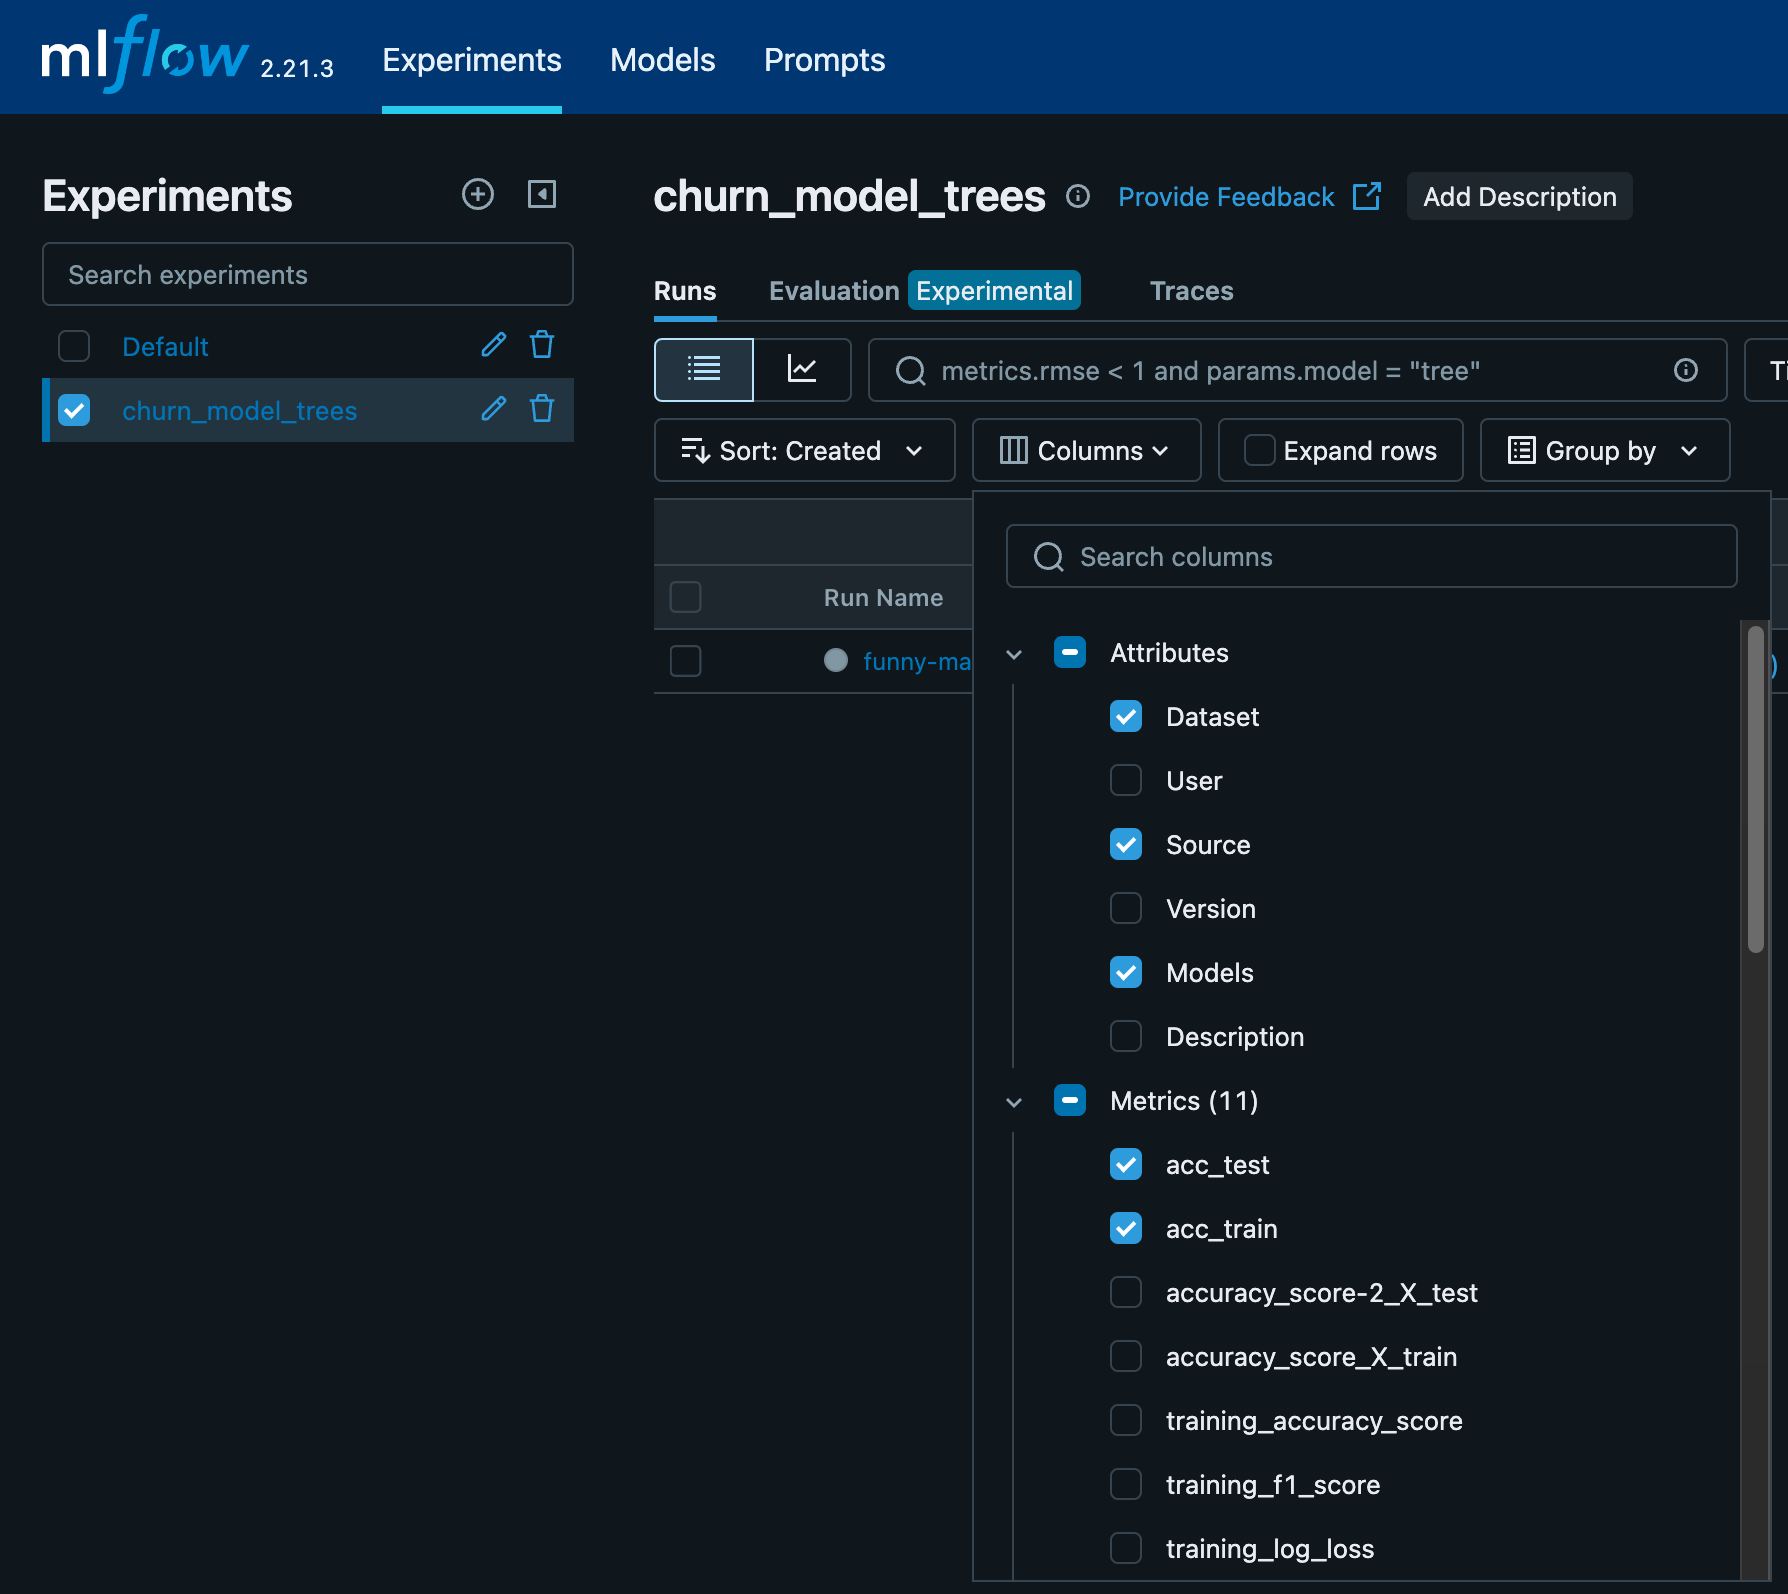

In [18]:
# Checking run's logged assets
Image(filename= "./img/experiment_metrics.png", width=500)

**Tune Model**<br>
Next, we want to try to optimize our model, tunning its hyperparameters. Each time we do it, a new ```run``` will be logged!

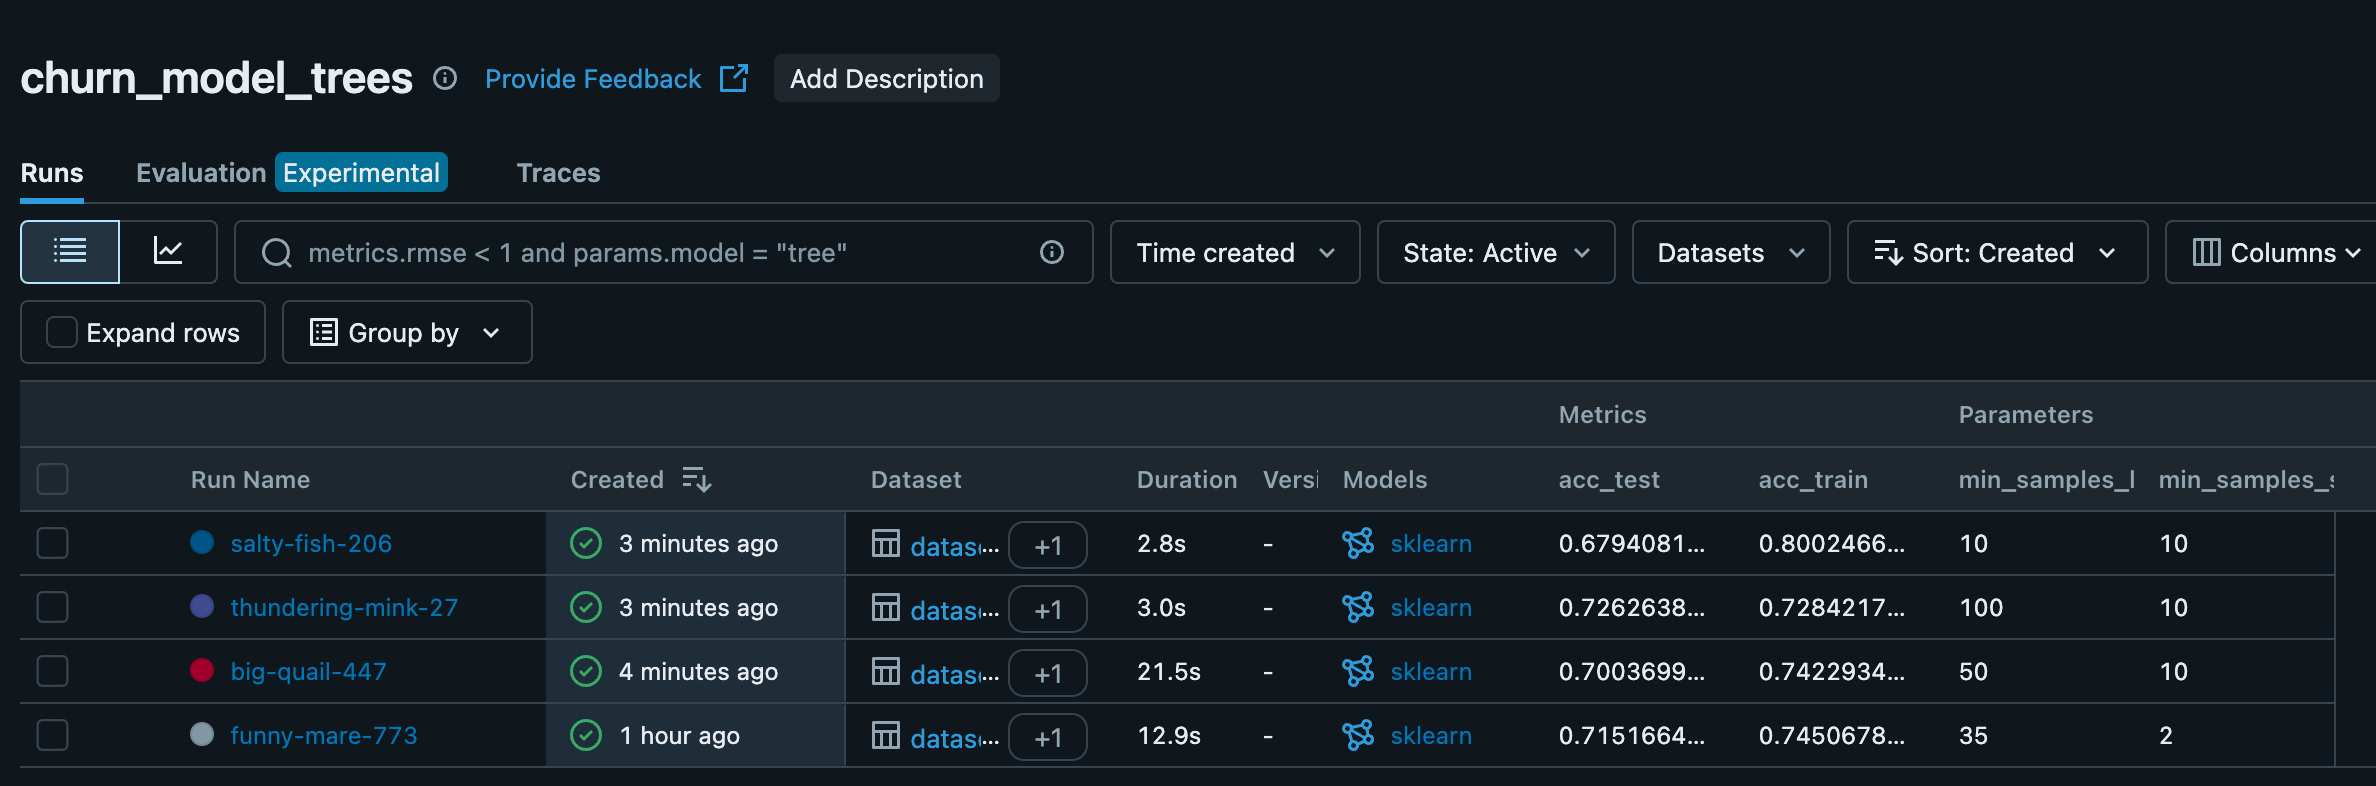

In [21]:
# Measuring the performance of all runs
Image(filename= "./img/all_runs.png", width=800)

**Registering the Best Model**<br>
After several runs, we notice that the best ```run``` (according to ```acc_test```) was ```thundering-mink-27``` with a ```0.7262```. Therefore, since we want this in production, we enter the ```run``` and click ```Register model``` (top right), choosing the ```MLflow Model``` it should be registered to.

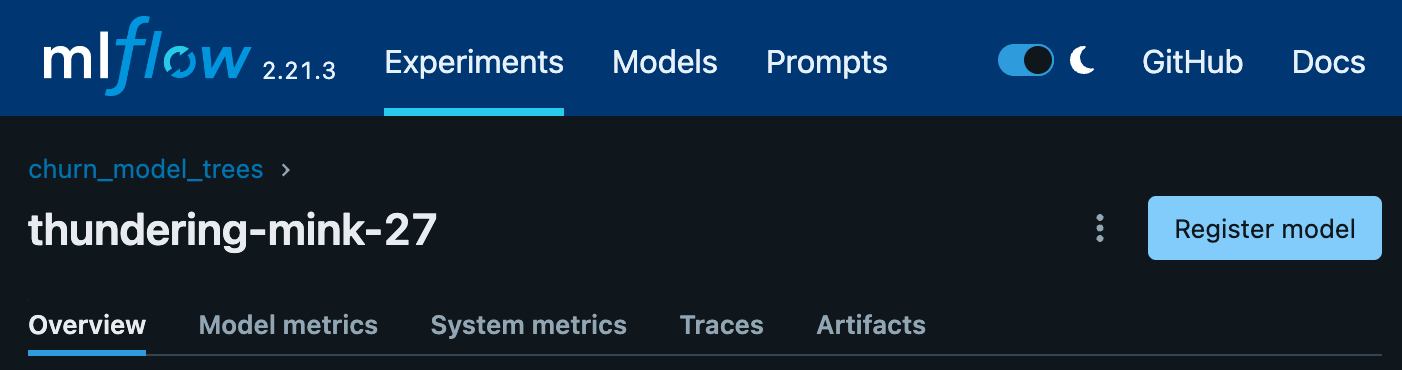

In [24]:
# Registering the model (with best run)
Image(filename= "./img/model_register.png", width=450)

Once registered, the button turns into ```Model registered```, showing that the ```run``` is in fact registered. When we click it, we can see the ```Model``` the ```run``` was registered to, as its first ```Version```:

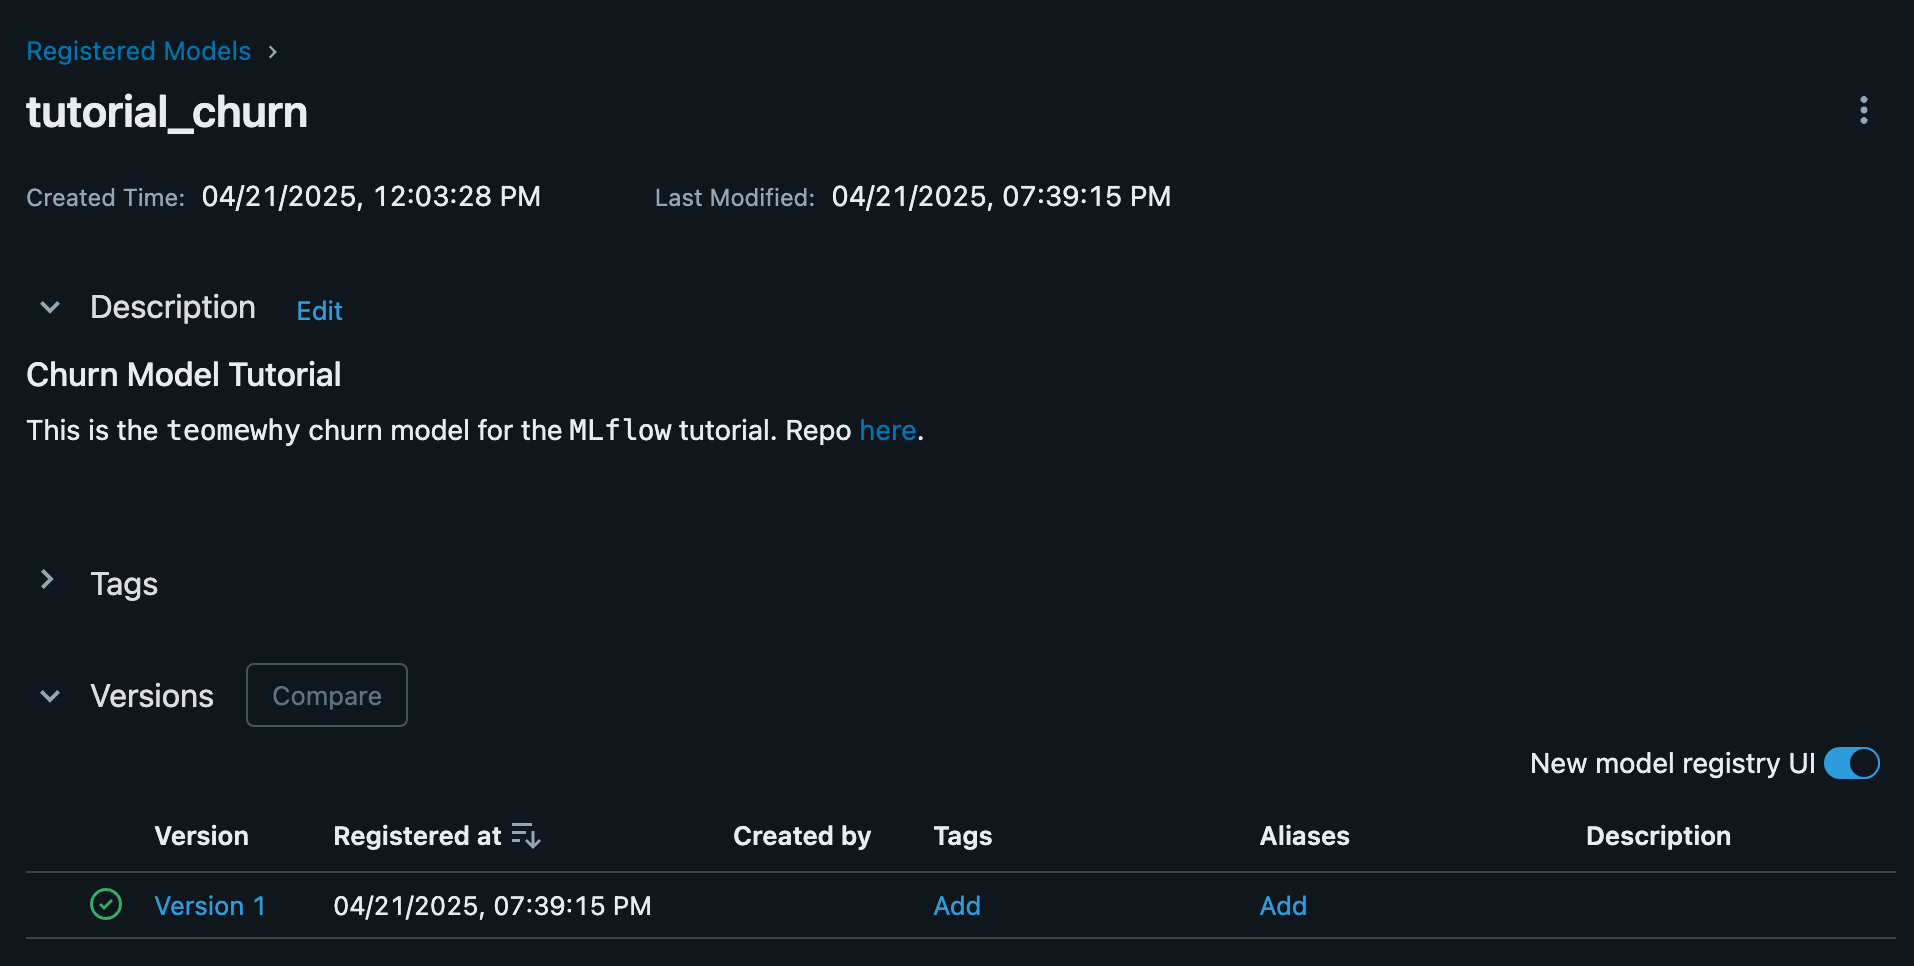

In [25]:
# Checking the model (with its first version)
Image(filename= "./img/model_first_version.png", width=450)

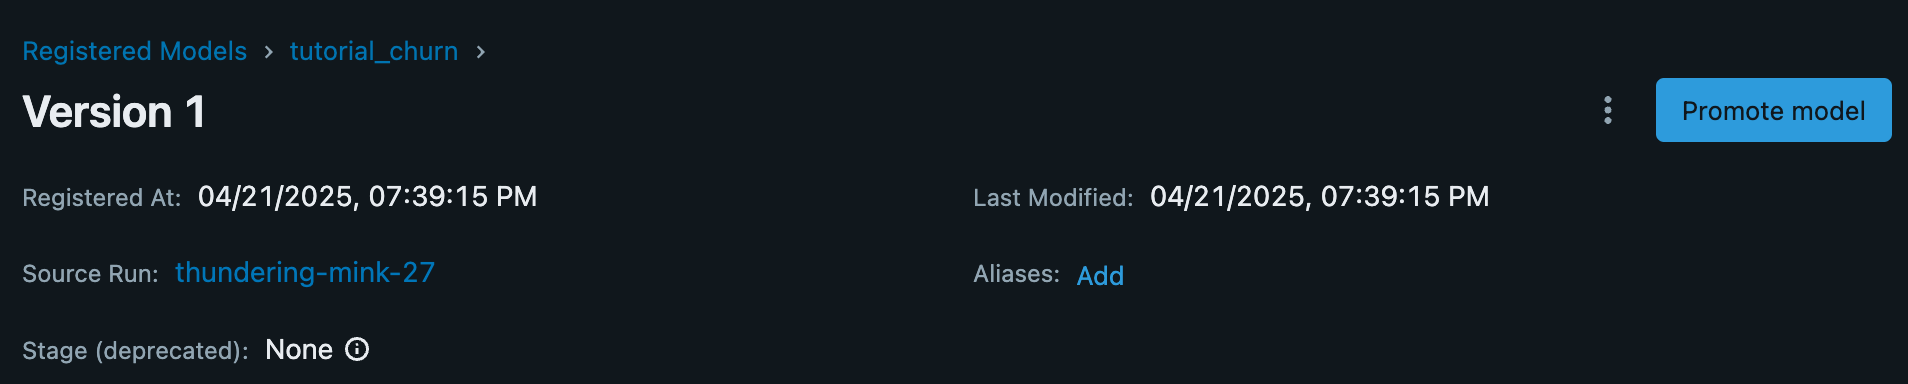

In [27]:
# Checking the first version itself
Image(filename= "./img/model_first_version_details.png", width=600)

**Tagging/Aliasing the Model**<br>
To make it easier to find our ```model version```, we can tag/alias it using the UI. We'll add 2 tags (```status: production``` and ```validation: pending```) and alias it as ```best```. 

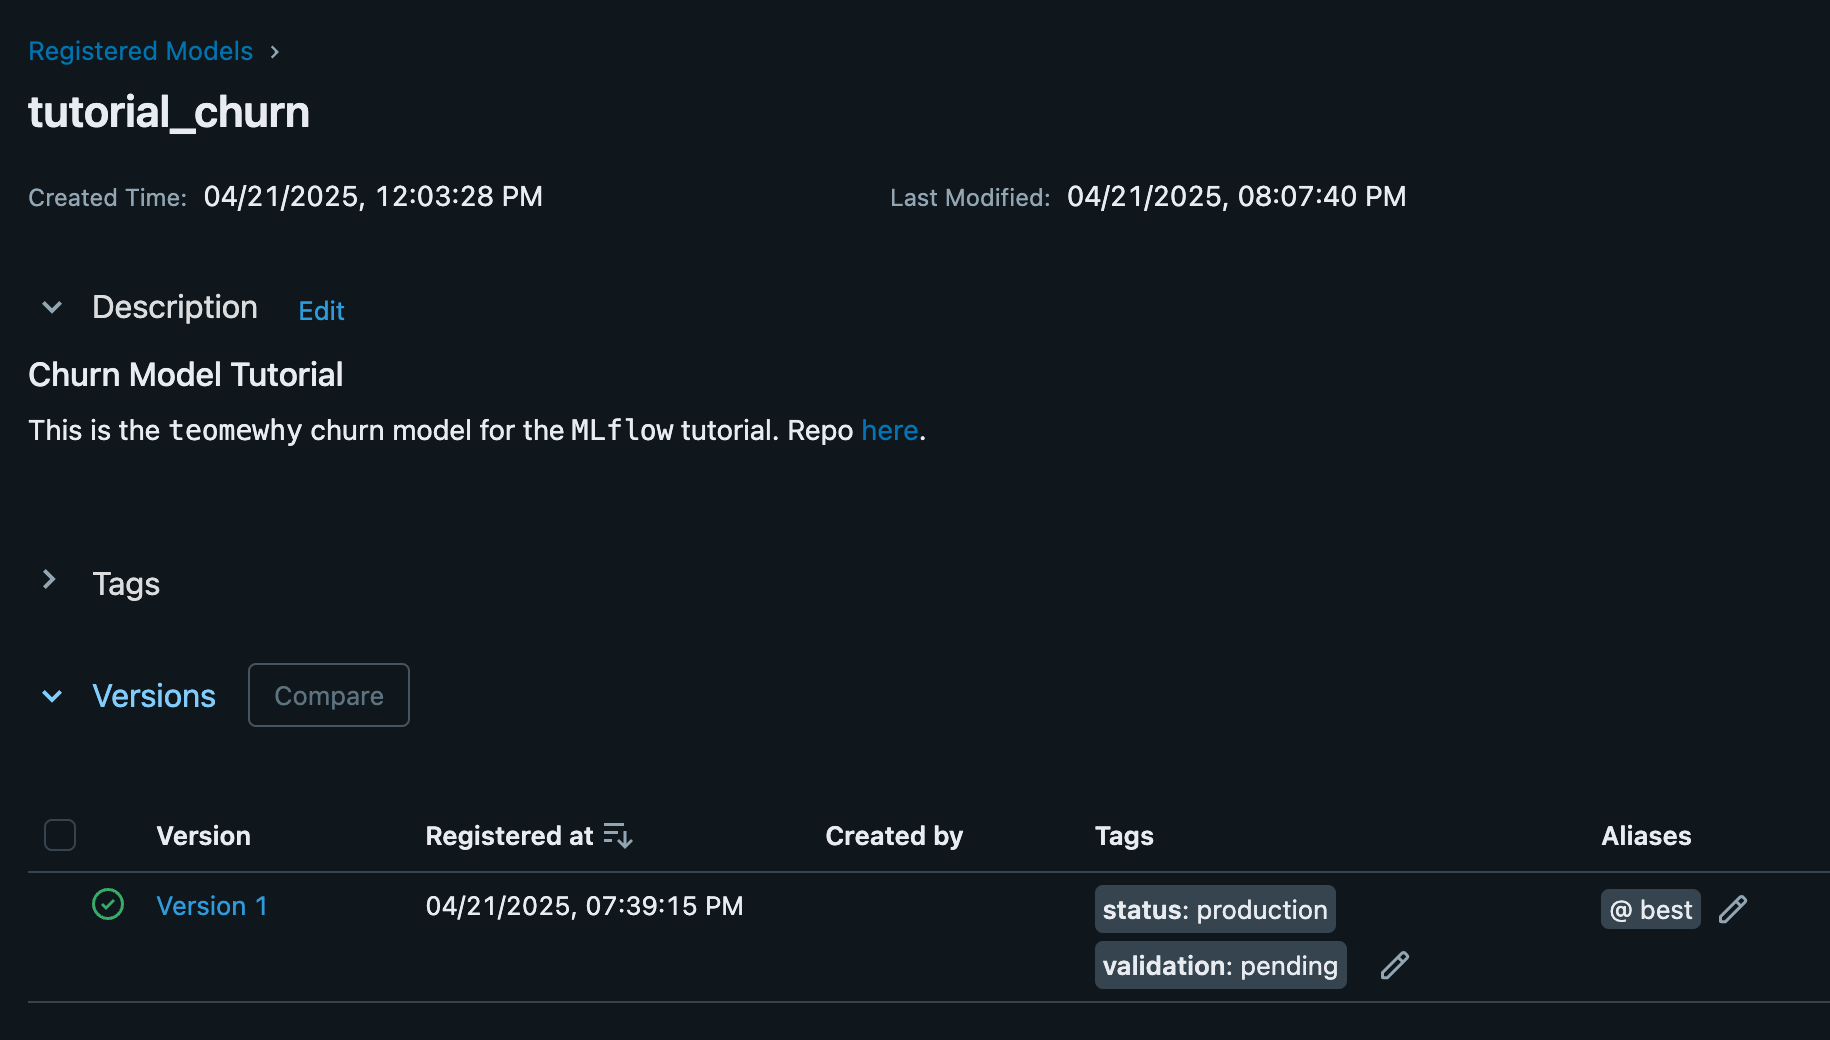

In [33]:
# Adding tags to the model version
Image(filename= "./img/model_tags_alias.png", width=500)

**Consuming the Model**<br>
Now that our best ```run``` is registered to our ```Model```, we want to consume it to make predictions on new data. We go back to ```VSCode``` and create the ```predict.py``` file.

We use the ```client```'s ```get_model_version_by_alias()``` method to access the registered (and aliased) ```model version``` and ```sklearn.load_model()``` to load it in a variable.

**Prediction**<br>
Finally, with the loaded ```model version```, we can use it for predictions.

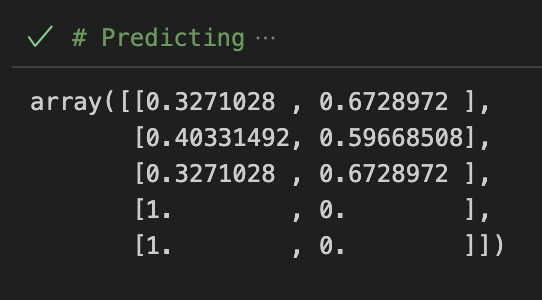

In [35]:
# Prediction results 
Image(filename= "./img/prediction.png", width=250)

---